# MNIST SVM comparison + Optuna tuning

This Colab-ready notebook:
- downloads MNIST via `torchvision`;
- shows sample images and class histogram;
- trains SVM classifiers (One-vs-One and One-vs-Rest) with **linear**, **polynomial**, and **RBF** kernels on **MNIST** **without PCA**;
- collects fit and predict times (train and test), shows accuracy and confusion matrices;
- uses Optuna to tune the RBF kernel (searching `C` and `gamma`);
- outputs summary tables and saves results.

**Notes**
- Training non-linear SVMs on the full MNIST (60k train, 10k test) can be slow. You can reduce `MAX_TRAIN_SAMPLES` to a smaller number for quick experiments.
- This notebook is designed to run on Google Colab. If you run locally, ensure packages are installed.


In [ ]:
# Install dependencies (run once in Colab)
!pip install -q torchvision optuna scikit-learn seaborn joblib
print("Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 5.0 MB/s eta 0:00:00
Packages installed


In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import time
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import torchvision
from torchvision import transforms
import torch
import optuna
import joblib

print("Imports ready")

Imports ready


In [ ]:
# Download MNIST and convert to numpy arrays
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def dataset_to_numpy(ds):
    X = np.stack([np.asarray(ds[i][0]).squeeze() for i in range(len(ds))])  # (N,28,28)
    X = X.reshape(len(ds), -1).astype(np.float32)  # (N,784)
    y = np.array([int(ds[i][1]) for i in range(len(ds))])
    return X, y

X_train_full, y_train_full = dataset_to_numpy(trainset)
X_test, y_test = dataset_to_numpy(testset)

print("Train full shape:", X_train_full.shape, "Test shape:", X_test.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 447kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.05MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.18MB/s]


Train full shape: (60000, 784) Test shape: (10000, 784)


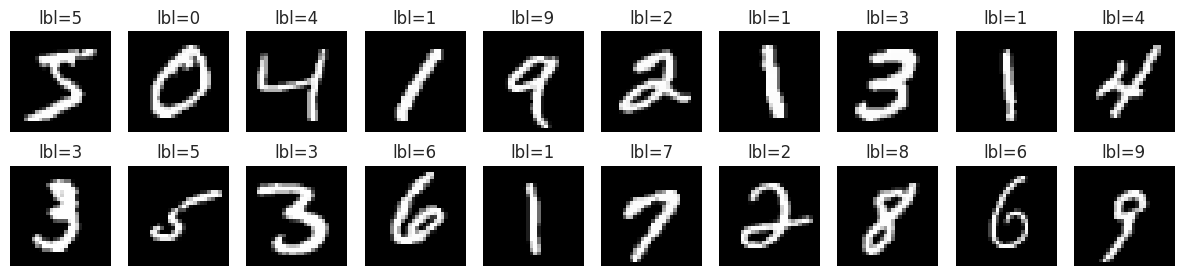

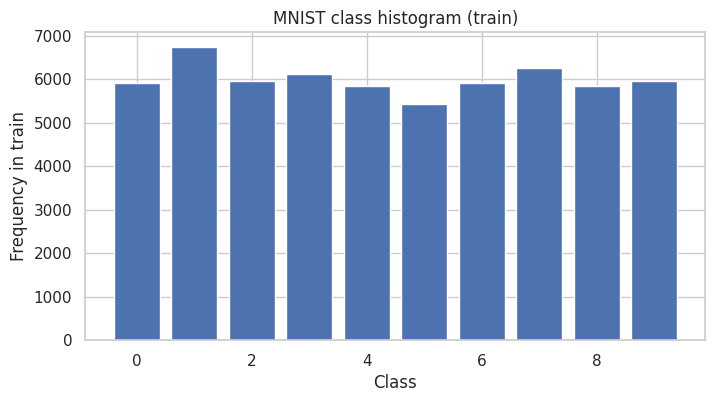

In [ ]:
# Plot some samples and class histogram
def plot_samples(X, y, n_per_row=10):
    n = n_per_row * 2
    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(2, n_per_row, i+1)
        plt.imshow(X[i].reshape(28,28), cmap='gray')
        plt.title(f"lbl={y[i]}")
        plt.axis('off')
    plt.tight_layout()

plot_samples(X_train_full, y_train_full, n_per_row=10)

plt.figure(figsize=(8,4))
plt.bar(np.arange(10), np.bincount(y_train_full))
plt.xlabel("Class")
plt.ylabel("Frequency in train")
plt.title("MNIST class histogram (train)")
plt.show()

In [ ]:
# Preprocessing. Optionally limit size for speed.
MAX_TRAIN_SAMPLES = 10000  # set to an integer (e.g., 10000) to speed up experiments or 'None'

if MAX_TRAIN_SAMPLES is None or MAX_TRAIN_SAMPLES >= X_train_full.shape[0]:
    X_train_sub, y_train_sub = X_train_full, y_train_full
else:
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train_full, y_train_full, train_size=MAX_TRAIN_SAMPLES, stratify=y_train_full, random_state=42)

print("Using train subset shape:", X_train_sub.shape)

scaler = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_sub)
X_test_proc = scaler.transform(X_test)
print("Final shapes:", X_train_proc.shape, X_test_proc.shape)

Using train subset shape: (10000, 784)
Final shapes: (10000, 784) (10000, 784)


In [ ]:
# Helpers: evaluate, timing, confusion plot
def evaluate_classifier(clf, X_train, y_train, X_test, y_test, name="clf", verbose=True):
    t0 = time.time()
    clf.fit(X_train, y_train)
    fit_time = time.time() - t0
    t0 = time.time()
    y_pred_train = clf.predict(X_train)
    predict_train_time = time.time() - t0
    t0 = time.time()
    y_pred_test = clf.predict(X_test)
    predict_test_time = time.time() - t0
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)
    if verbose:
        print(f"{name}: fit {fit_time:.2f}s | pred_train {predict_train_time:.2f}s | pred_test {predict_test_time:.2f}s | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")
    return {"clf": clf, "train_acc": train_acc, "test_acc": test_acc, "y_pred_train": y_pred_train, "y_pred_test": y_pred_test, "fit_time": fit_time, "pred_train_time": predict_train_time, "pred_test_time": predict_test_time}

def plot_confusion(y_true, y_pred, labels=None, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(title)
    plt.show()

=== Kernel: linear ===

OvO SVC (linear): fit 9.76s | pred_train 34.01s | pred_test 43.15s | train acc: 1.0000 | test acc: 0.9159


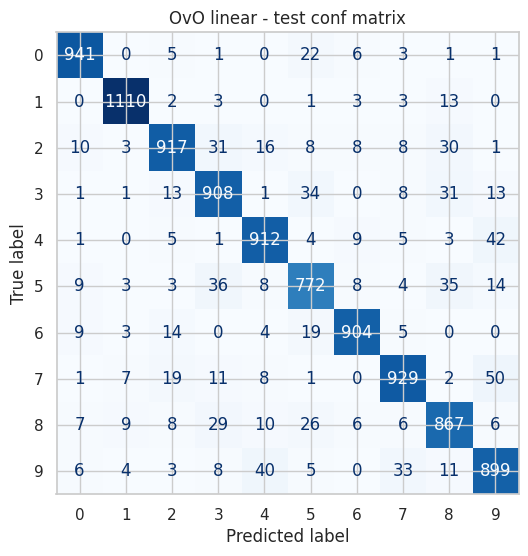

OvA SVC (linear): fit 235.25s | pred_train 16.12s | pred_test 16.40s | train acc: 0.9710 | test acc: 0.8773


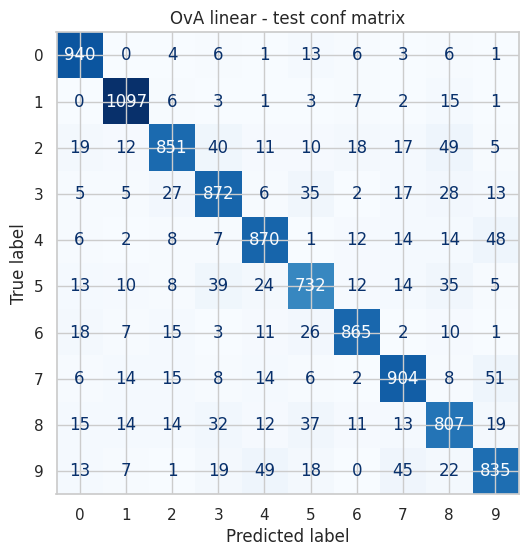



=== Kernel: poly ===

OvO SVC (poly): fit 45.89s | pred_train 222.21s | pred_test 213.73s | train acc: 0.9437 | test acc: 0.9073


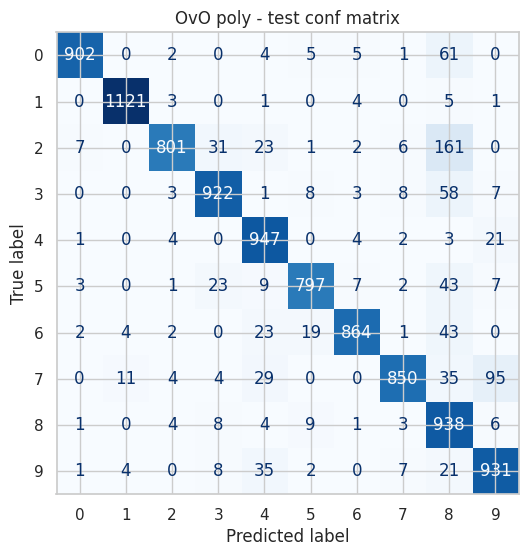

OvA SVC (poly): fit 204.37s | pred_train 85.94s | pred_test 79.38s | train acc: 0.9753 | test acc: 0.9405


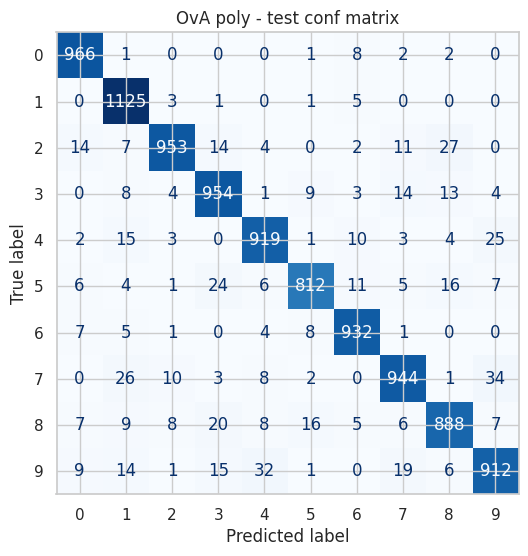



=== Kernel: rbf ===

OvO SVC (rbf): fit 16.77s | pred_train 265.97s | pred_test 270.42s | train acc: 0.9823 | test acc: 0.9435


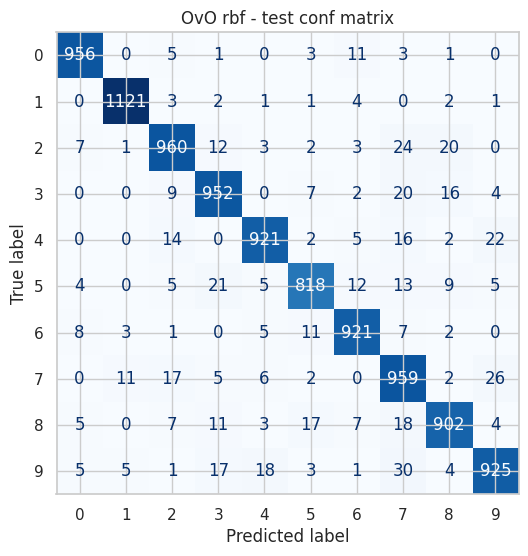

OvA SVC (rbf): fit 82.97s | pred_train 92.45s | pred_test 91.66s | train acc: 0.9789 | test acc: 0.9424


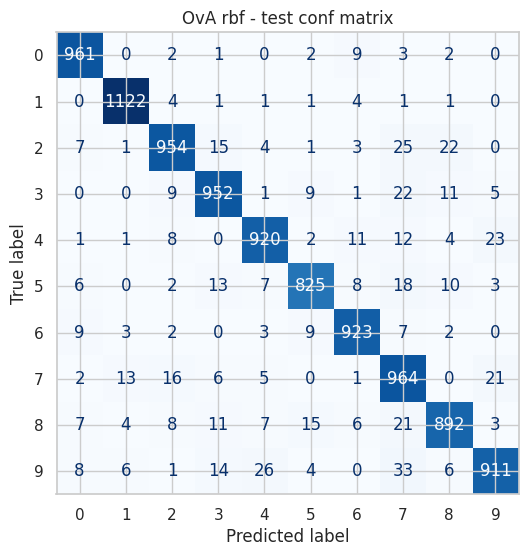

In [ ]:
# Compare kernels and OvO vs OvA; collect timings and metrics
kernels = {
    "linear": {"kernel":"linear"},
    "poly": {"kernel":"poly", "degree":3, "gamma":"scale"},
    "rbf": {"kernel":"rbf", "gamma":"scale"}
}

results = []
for kernel_name, kernel_params in kernels.items():
    print("=== Kernel:", kernel_name, "===\n")
    base = SVC(C=1.0, **{k:v for k,v in kernel_params.items()})
    clf_ovo = OneVsOneClassifier(base)
    res_ovo = evaluate_classifier(clf_ovo, X_train_proc, y_train_sub, X_test_proc, y_test, name=f"OvO SVC ({kernel_name})")
    results.append(("OvO", kernel_name, res_ovo))
    plot_confusion(y_test, res_ovo["y_pred_test"], labels=list(range(10)), title=f"OvO {kernel_name} - test conf matrix")

    base2 = SVC(C=1.0, **{k:v for k,v in kernel_params.items()})
    clf_ova = OneVsRestClassifier(base2)
    res_ova = evaluate_classifier(clf_ova, X_train_proc, y_train_sub, X_test_proc, y_test, name=f"OvA SVC ({kernel_name})")
    results.append(("OvA", kernel_name, res_ova))
    plot_confusion(y_test, res_ova["y_pred_test"], labels=list(range(10)), title=f"OvA {kernel_name} - test conf matrix")
    print("\n")

In [ ]:
# Summary table of results
rows = []
for mode, kernel, res in results:
    rows.append({
        "mode": mode,
        "kernel": kernel,
        "train_acc": res["train_acc"],
        "test_acc": res["test_acc"],
        "fit_time_s": res["fit_time"],
        "pred_train_s": res["pred_train_time"],
        "pred_test_s": res["pred_test_time"]
    })
df = pd.DataFrame(rows)
display(df.sort_values(by=["test_acc"], ascending=False))

,mode,kernel,train_acc,test_acc,fit_time_s,pred_train_s,pred_test_s
4,OvO,rbf,0.9823,0.9435,16.773923,265.968753,270.424176
5,OvA,rbf,0.9789,0.9424,82.968986,92.447080,91.658285
3,OvA,poly,0.9753,0.9405,204.372126,85.939250,79.378891
0,OvO,linear,1.0000,0.9159,9.759373,34.009007,43.149732
2,OvO,poly,0.9437,0.9073,45.885778,222.209663,213.734654
1,OvA,linear,0.9710,0.8773,235.253719,16.122027,16.401563


In [ ]:
# Optuna tuning for RBF SVC (on the current training subset)
def optuna_objective(trial):
    C = trial.suggest_float("C", 1e-3, 1e3,log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1e1,log=True)
    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    scores = cross_val_score(clf, X_train_proc, y_train_sub, cv=3, scoring="accuracy", n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
N_TRIALS = 30  # increase for better search
study.optimize(optuna_objective, n_trials=N_TRIALS)

print("Best trial:", study.best_trial.params, "best_score:", study.best_value)

[I 2026-03-14 09:27:33,464] A new study created in memory with name: no-name-7c3e91a5-adfd-4eb1-8c90-872497ce4d3b
[I 2026-03-14 09:28:17,024] Trial 0 finished with value: 0.9379997087891153 and parameters: {'C': 11.567466055802013, 'gamma': 0.0008426581628903635}. Best is trial 0 with value: 0.9379997087891153.
[I 2026-03-14 09:30:47,300] Trial 1 finished with value: 0.6345000126887314 and parameters: {'C': 795.6394052725013, 'gamma': 0.016066569895285675}. Best is trial 0 with value: 0.9379997087891153.
[I 2026-03-14 09:33:29,478] Trial 2 finished with value: 0.11239999224877496 and parameters: {'C': 0.002213416568682024, 'gamma': 4.858336254398503}. Best is trial 0 with value: 0.9379997087891153.
[I 2026-03-14 09:34:59,848] Trial 3 finished with value: 0.9185000683631651 and parameters: {'C': 4.6312473338543825, 'gamma': 0.00309233722946269}. Best is trial 0 with value: 0.9379997087891153.
[I 2026-03-14 09:37:58,036] Trial 4 finished with value: 0.7541992651574696 and parameters: {'C

Best trial: {'C': 4.253571671065662, 'gamma': 0.0010937602796965123} best_score: 0.9381996687971137


RBF SVC best (Optuna): fit 18.28s | pred_train 45.09s | pred_test 48.68s | train acc: 0.9949 | test acc: 0.9476


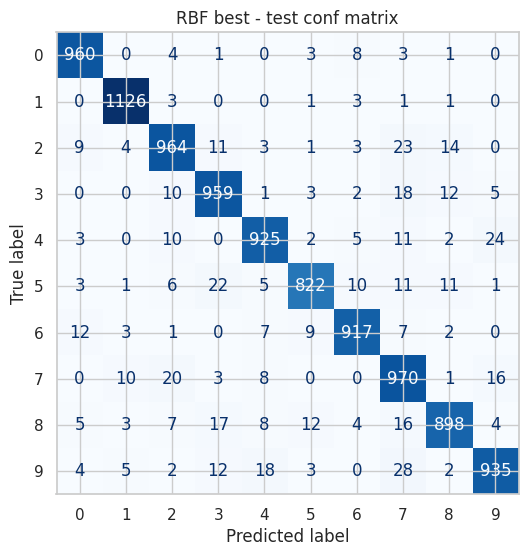

In [ ]:
# Retrain best RBF found and evaluate
best_params = study.best_trial.params
clf_best = SVC(kernel="rbf", C=best_params["C"], gamma=best_params["gamma"])
res_best = evaluate_classifier(clf_best, X_train_proc, y_train_sub, X_test_proc, y_test, name="RBF SVC best (Optuna)")
plot_confusion(y_test, res_best["y_pred_test"], labels=list(range(10)), title="RBF best - test conf matrix")

## Notes & Next steps

- To run the notebook faster, set `MAX_TRAIN_SAMPLES` to a smaller number (e.g., 10000).
- You can increase `N_TRIALS` in the Optuna block to search more thoroughly.
- For reproducibility, set random seeds where appropriate.

---